# Artefato 2: Modelo Clássico Baseline (Machine Learning Tradicional)


## 1. Configuracao do ambiente e carregamento dos dados

Configura paths, importa modulos do pipeline e carrega o dataset tabular de pixels com rotulos derivados de `extracted_codes.json`.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Resolve a raiz do repositorio para imports internos
repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.utils.prepare_dataset import prepare_dataset

# Caminhos dos dados
PIXELS_DATASET_PATH = str(repo_root / "data" / "pixels_dataset.csv")
EXTRACTED_CODES_PATH = str(repo_root / "data" / "extracted_codes.json")

# Carrega features e labels
X, y = prepare_dataset(PIXELS_DATASET_PATH, EXTRACTED_CODES_PATH)
print(f"Features: {X.shape}")
print(f"Labels:   {y.shape}")
print(f"Distribuicao das classes:\n{y.value_counts()}")

/Users/mateus/Projetos/Academico/Inteli/g01/src/utils/prepare_dataset.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['image_id'] = df['path'].str.extract(regex)[0]
/Users/mateus/Projetos/Academico/Inteli/g01/src/utils/prepare_dataset.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = df['image_id'].apply(


Features: (295, 147456)
Labels:   (295,)
Distribuicao das classes:
label
0    179
1    116
Name: count, dtype: int64


## 2. Divisao treino / teste (stratified)

Separa 80% para treino e 20% para teste, mantendo a proporcao de classes com `stratify`. O `random_state` garante reprodutibilidade.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino:  {X_train.shape}  |  positivos={sum(y_train==1)}, negativos={sum(y_train==0)}")
print(f"Teste:   {X_test.shape}  |  positivos={sum(y_test==1)}, negativos={sum(y_test==0)}")

Treino:  (236, 147456)  |  positivos=93, negativos=143
Teste:   (59, 147456)  |  positivos=23, negativos=36


## 3. Ajuste do hiperparametro C via GridSearchCV

Construimos um pipeline `StandardScaler` + `SVC(kernel='linear')` e testamos diferentes valores de `C` com validacao cruzada estratificada (5-fold). A metrica de selecao e o F1-score, alinhada com a secao 1.3 do artefato 1.

In [4]:
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", probability=True, random_state=42)),
])

param_grid = {"svm__C": [0.001, 0.01, 0.1, 1, 10, 100]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline_svm,
    param_grid,
    cv=cv,
    scoring="f1",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"\nMelhor C: {grid_search.best_params_['svm__C']}")
print(f"Melhor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Users/mateus/Projetos/Academico/Inteli/g01/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Melhor C: 0.001
Melhor F1 (CV): 0.7658


### 3.1 Resultados da busca de C

Visualiza o F1-score medio de treino e validacao para cada valor de C testado.

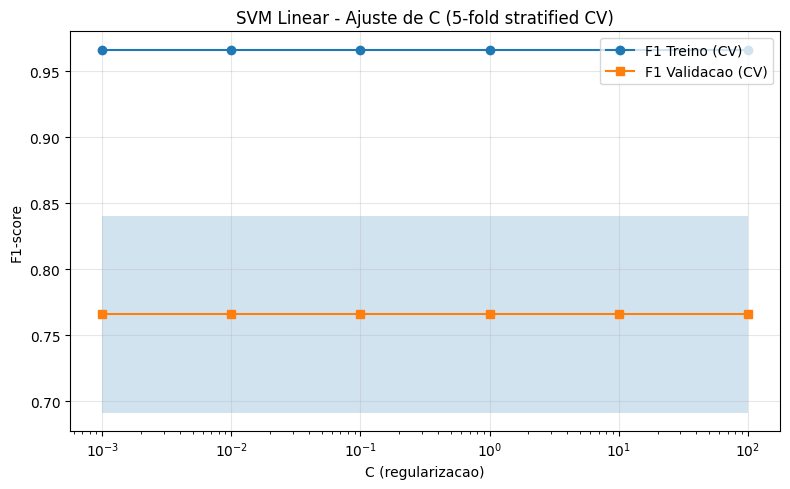


Resumo por valor de C:
      C  F1 Treino (media)  F1 Val (media)  F1 Val (std)
  0.001           0.966625        0.765848      0.074599
  0.010           0.966625        0.765848      0.074599
  0.100           0.966625        0.765848      0.074599
  1.000           0.966625        0.765848      0.074599
 10.000           0.966625        0.765848      0.074599
100.000           0.966625        0.765848      0.074599


In [5]:
results_df = pd.DataFrame(grid_search.cv_results_)

fig, ax = plt.subplots(figsize=(8, 5))
c_values = results_df["param_svm__C"].astype(float)
ax.plot(c_values, results_df["mean_train_score"], "o-", label="F1 Treino (CV)")
ax.plot(c_values, results_df["mean_test_score"], "s-", label="F1 Validacao (CV)")
ax.fill_between(
    c_values,
    results_df["mean_test_score"] - results_df["std_test_score"],
    results_df["mean_test_score"] + results_df["std_test_score"],
    alpha=0.2,
)
ax.set_xscale("log")
ax.set_xlabel("C (regularizacao)")
ax.set_ylabel("F1-score")
ax.set_title("SVM Linear - Ajuste de C (5-fold stratified CV)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nResumo por valor de C:")
summary = results_df[["param_svm__C", "mean_train_score", "mean_test_score", "std_test_score"]]
summary.columns = ["C", "F1 Treino (media)", "F1 Val (media)", "F1 Val (std)"]
print(summary.to_string(index=False))

## 4. Avaliacao no conjunto de teste

Utiliza o melhor modelo encontrado pelo GridSearchCV para predizer no conjunto de teste (hold-out) e calcula as metricas definidas no artefato 1 (secao 1.3): **F1-score**, **ROC-AUC**, **Recall**, **Precision** e **Accuracy**.

In [6]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall":    recall_score(y_test, y_pred, zero_division=0),
    "F1-score":  f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, y_prob),
}

print("=" * 45)
print(f"  SVM Linear (C={grid_search.best_params_['svm__C']})")
print("=" * 45)
for name, value in metrics.items():
    print(f"  {name:<12s}: {value:.4f}")
print("=" * 45)

# Criterios de aceitacao (artefato 1, secao 1.3)
print("\nCriterios de aceitacao:")
print(f"  ROC-AUC >= 0.70 : {'OK' if metrics['ROC-AUC'] >= 0.70 else 'ABAIXO'} ({metrics['ROC-AUC']:.4f})")
print(f"  F1-score >= 0.60: {'OK' if metrics['F1-score'] >= 0.60 else 'ABAIXO'} ({metrics['F1-score']:.4f})")
print(f"  Recall >= 0.65  : {'OK' if metrics['Recall'] >= 0.65 else 'ABAIXO'} ({metrics['Recall']:.4f})")

  SVM Linear (C=0.001)
  Accuracy    : 0.8644
  Precision   : 0.8571
  Recall      : 0.7826
  F1-score    : 0.8182
  ROC-AUC     : 0.9233

Criterios de aceitacao:
  ROC-AUC >= 0.70 : OK (0.9233)
  F1-score >= 0.60: OK (0.8182)
  Recall >= 0.65  : OK (0.7826)


### 4.1 Classification Report

In [7]:
print(classification_report(y_test, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))

              precision    recall  f1-score   support

Negativo (0)       0.87      0.92      0.89        36
Positivo (1)       0.86      0.78      0.82        23

    accuracy                           0.86        59
   macro avg       0.86      0.85      0.86        59
weighted avg       0.86      0.86      0.86        59



### 4.2 Matriz de Confusao

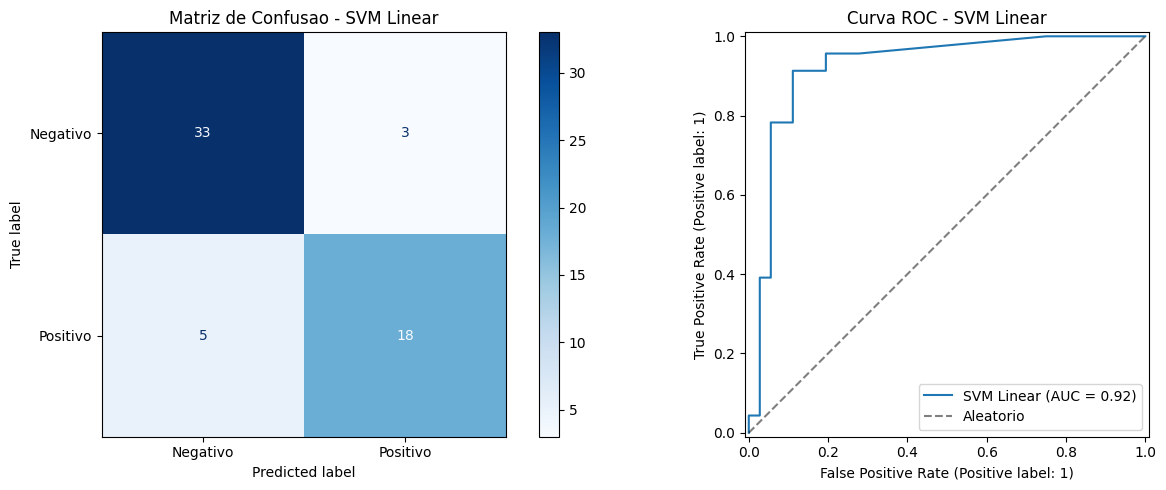

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusao
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Negativo", "Positivo"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Matriz de Confusao - SVM Linear")

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name="SVM Linear",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatorio")
axes[1].set_title("Curva ROC - SVM Linear")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Validacao cruzada completa (5-fold) com o melhor C

Para obter uma estimativa mais robusta do desempenho, rodamos validacao cruzada estratificada no conjunto de treino inteiro com o melhor C encontrado.

In [9]:
best_C = grid_search.best_params_["svm__C"]

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=best_C, probability=True, random_state=42)),
])

scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

print(f"Validacao cruzada (5-fold) com C={best_C}\n")
for metric in scoring_metrics:
    scores = cross_val_score(final_pipeline, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    print(f"  {metric:<12s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Validacao cruzada (5-fold) com C=0.001

  accuracy    : 0.8138 (+/- 0.0565)


/Users/mateus/Projetos/Academico/Inteli/g01/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  precision   : 0.7587 (+/- 0.0688)
  recall      : 0.7754 (+/- 0.0889)


/Users/mateus/Projetos/Academico/Inteli/g01/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  f1          : 0.7658 (+/- 0.0746)
  roc_auc     : 0.8535 (+/- 0.0620)


## 6. Resumo das metricas

Consolida as metricas do baseline SVM linear em uma tabela para referencia nos proximos artefatos.

In [10]:
summary_df = pd.DataFrame([{
    "Modelo": "SVM Linear",
    "C": best_C,
    "Accuracy": round(metrics["Accuracy"], 4),
    "Precision": round(metrics["Precision"], 4),
    "Recall": round(metrics["Recall"], 4),
    "F1-score": round(metrics["F1-score"], 4),
    "ROC-AUC": round(metrics["ROC-AUC"], 4),
}])

print(summary_df.to_string(index=False))

    Modelo     C  Accuracy  Precision  Recall  F1-score  ROC-AUC
SVM Linear 0.001    0.8644     0.8571  0.7826    0.8182   0.9233


In [11]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.utils.prepare_dataset import prepare_dataset

PIXELS_DATASET_PATH = str(repo_root / "data" / "pixels_dataset.csv")
EXTRACTED_CODES_PATH = str(repo_root / "data" / "extracted_codes.json")

X, y = prepare_dataset(PIXELS_DATASET_PATH, EXTRACTED_CODES_PATH)
print(f"Features: {X.shape}")
print(f"Labels:   {y.shape}")
print(f"\nDistribuicao das classes:\n{y.value_counts()}")
print(f"\nLabels unicos: {sorted(y.unique())}")

/Users/mateus/Projetos/Academico/Inteli/g01/src/utils/prepare_dataset.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['image_id'] = df['path'].str.extract(regex)[0]
/Users/mateus/Projetos/Academico/Inteli/g01/src/utils/prepare_dataset.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = df['image_id'].apply(


Features: (295, 147456)
Labels:   (295,)

Distribuicao das classes:
label
0    179
1    116
Name: count, dtype: int64

Labels unicos: [np.int64(0), np.int64(1)]


In [12]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino:  {X_train.shape}  |  positivos={sum(y_train==1)}, negativos={sum(y_train==0)}")
print(f"Teste:   {X_test.shape}  |  positivos={sum(y_test==1)}, negativos={sum(y_test==0)}")

Treino:  (236, 147456)  |  positivos=93, negativos=143
Teste:   (59, 147456)  |  positivos=23, negativos=36


In [13]:
# GridSearchCV - ajuste de C
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", probability=True, random_state=42)),
])

param_grid = {"svm__C": [0.001, 0.01, 0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline_svm, param_grid, cv=cv, scoring="f1",
    return_train_score=True, n_jobs=-1, verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"\nMelhor C: {grid_search.best_params_['svm__C']}")
print(f"Melhor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Users/mateus/Projetos/Academico/Inteli/g01/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Melhor C: 0.001
Melhor F1 (CV): 0.7658


In [14]:
# Resultados detalhados do GridSearch
results_df = pd.DataFrame(grid_search.cv_results_)
summary = results_df[["param_svm__C", "mean_train_score", "mean_test_score", "std_test_score"]]
summary.columns = ["C", "F1 Treino (media)", "F1 Val (media)", "F1 Val (std)"]
print(summary.to_string(index=False))

print(f"\nDiferenca treino-val por C:")
for _, row in summary.iterrows():
    gap = row["F1 Treino (media)"] - row["F1 Val (media)"]
    print(f"  C={row['C']:<6}  gap={gap:.4f}  {'<-- OVERFITTING' if gap > 0.15 else ''}")

      C  F1 Treino (media)  F1 Val (media)  F1 Val (std)
  0.001           0.966625        0.765848      0.074599
  0.010           0.966625        0.765848      0.074599
  0.100           0.966625        0.765848      0.074599
  1.000           0.966625        0.765848      0.074599
 10.000           0.966625        0.765848      0.074599
100.000           0.966625        0.765848      0.074599

Diferenca treino-val por C:
  C=0.001   gap=0.2008  <-- OVERFITTING
  C=0.01    gap=0.2008  <-- OVERFITTING
  C=0.1     gap=0.2008  <-- OVERFITTING
  C=1.0     gap=0.2008  <-- OVERFITTING
  C=10.0    gap=0.2008  <-- OVERFITTING
  C=100.0   gap=0.2008  <-- OVERFITTING


In [15]:
# Metricas no conjunto de teste
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall":    recall_score(y_test, y_pred, zero_division=0),
    "F1-score":  f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, y_prob),
}

for name, value in metrics.items():
    print(f"  {name:<12s}: {value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))

print(f"Matriz de confusao:")
print(confusion_matrix(y_test, y_pred))

  Accuracy    : 0.8644
  Precision   : 0.8571
  Recall      : 0.7826
  F1-score    : 0.8182
  ROC-AUC     : 0.9233

Classification Report:
              precision    recall  f1-score   support

Negativo (0)       0.87      0.92      0.89        36
Positivo (1)       0.86      0.78      0.82        23

    accuracy                           0.86        59
   macro avg       0.86      0.85      0.86        59
weighted avg       0.86      0.86      0.86        59

Matriz de confusao:
[[33  3]
 [ 5 18]]


### Baseline de Regressão Logistica

Treinar RL com regularização L2 e validar em conjunto de validação; registrar métricas. Entrega: função e resultados.

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import json
import re
import sys
import os

In [6]:
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), "../../src")))
from models.pipeline_factory import train_classification 

# --- CONSTANTES ADAPTADAS PARA SUA TASK ---
MODEL_NAME = "logisticregression"
MODEL_PARAMS = {
    "penalty": "l2",      
    "C": 1.0,               
    "solver": "lbfgs",     
    "max_iter": 1000,       
    "random_state": 42
}

PIXELS_DATASET_PATH = "pixels_dataset.csv"
EXTRACTED_CODES_PATH = "extracted_codes.json"

### Preparação dos dados para mapear os dados para o formato esperado pelo modelo de regressão logística. 

In [ ]:
def prepare_dataset(dataset_path: str, extracted_codes_path: str):
    df = pd.read_csv(dataset_path)

    with open(extracted_codes_path, 'r') as f:
        extracted_codes = json.load(f)

    # Lógica de extração de ID do colega
    all_ids = extracted_codes['negativos'] + extracted_codes['positivos']
    all_ids_sorted = sorted(all_ids, key=len, reverse=True)
    id_pattern = '|'.join(re.escape(id_val) for id_val in all_ids_sorted)
    regex = rf'({id_pattern})'
    df['image_id'] = df['path'].str.extract(regex)[0]

    # Criação do Label (1=Positivo, 0=Negativo)
    df['label'] = df['image_id'].apply(
        lambda x: 1 if x in extracted_codes['positivos'] else (
            0 if x in extracted_codes['negativos'] else -1
        )
    )

    # Removemos os -1 (casos que não deram match no JSON) para não sujar a baseline
    df = df[df['label'] != -1].reset_index(drop=True)

    X = df.drop(
        columns=[
            'path', 'filename', 'count', 'height', 'width', 'dtype',
            'crs', 'transform', 'image_id', 'label'
        ]
    )
    y = df["label"]

    return X, y

In [8]:
# --- EXECUÇÃO: Preparação dos dados e treino do modelo ---
print(f"Iniciando Task: Baseline {MODEL_NAME}...")

X, y = prepare_dataset(PIXELS_DATASET_PATH, EXTRACTED_CODES_PATH)
print(f"Dataset preparado. Shape: {X.shape}. Classes: {np.bincount(y)}")

pipeline, metrics = train_classification(
    X,
    y,
    model_name=MODEL_NAME,
    **MODEL_PARAMS
)

print("\n=== RESULTADOS BASELINE REGRESSÃO LOGÍSTICA (L2) ===")
for k, v in metrics.items():
    print(f"{k.upper()}: {v:.4f}")

Iniciando Task: Baseline logisticregression...


/var/folders/st/r72pjbts3bb1zfh2s1r4pzw00000gn/T/ipykernel_62840/3514297434.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['image_id'] = df['path'].str.extract(regex)[0]
/var/folders/st/r72pjbts3bb1zfh2s1r4pzw00000gn/T/ipykernel_62840/3514297434.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = df['image_id'].apply(


Dataset preparado. Shape: (295, 147456). Classes: [179 116]


/Users/pedroauler/miniforge3/envs/Aster/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



=== RESULTADOS BASELINE REGRESSÃO LOGÍSTICA (L2) ===
ACCURACY: 0.7797
PRECISION: 0.6818
RECALL: 0.7143
F1: 0.6977
ROC_AUC: 0.8120
